# Recurrent Neural Networks (RNNs) and LSTMs

---
<a id='1'></a>
## 1. The Problem with Feedforward Networks on Sequences

Everything we have learned so far about feedforward (fully-connected) networks and CNNs shares one fundamental assumption:

> **Each input is processed independently of every other input.**

That is perfectly fine when inputs are independent — classifying an image of a cat has nothing to do with the previous image you showed the network. But now consider these tasks:

| Task | Why order / history matters |
|---|---|
| Predicting the next word in a sentence | "The bank by the **river**" vs "The bank by the **teller**" — the meaning of "bank" depends on previous words |
| Speech recognition | The sound of a phoneme depends on what came before it |
| Stock price prediction | Today's price depends on yesterday's (and last week's) |
| Video understanding | Frame 100 only makes sense in context of frames 1–99 |
| Machine translation | Word order changes between languages |

### Why can't a standard MLP just handle this?

You might think: *"Just concatenate the last N inputs and feed them in!"* This is called a **sliding window** approach and it does work — but it has hard limits:

- You must fix the window size **in advance** (what if the relevant context is 500 steps back?)
- The network has **no weight sharing across time** — what it learns about position 1 does not transfer to position 2
- It cannot handle **variable-length sequences** elegantly

We need a new architecture — one that maintains a **memory** of what it has seen and updates it at each step.

---
<a id='2'></a>
## 2. What is a Recurrent Neural Network?

A **Recurrent Neural Network (RNN)** is a neural network with a loop in it. At each time step, it:
1. Takes the current input $x_t$
2. Combines it with a **hidden state** $h_{t-1}$ (its memory from all previous steps)
3. Produces a new hidden state $h_t$
4. Optionally produces an output $y_t$

### The Core Equation

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

$$y_t = W_{hy} \cdot h_t + b_y$$

Where:
- $x_t$ — input at time step $t$
- $h_t$ — hidden state at time step $t$ (the "memory")
- $h_{t-1}$ — hidden state from the **previous** time step
- $W_{hh}$ — weight matrix for hidden-to-hidden connections (this is what makes it *recurrent*)
- $W_{xh}$ — weight matrix for input-to-hidden connections
- $W_{hy}$ — weight matrix for hidden-to-output connections
- $\tanh$ — the activation function (squashes values to $[-1, 1]$)

### 🔑 The Key Insight

The **same weights** ($W_{hh}$, $W_{xh}$, $W_{hy}$) are used at **every time step**. This is called **weight sharing across time**, and it is what allows an RNN to:
- Handle sequences of any length
- Generalize what it learns in one part of a sequence to another

Think of it like reading a book: you use the same brain at every word, but you carry a continuously updated mental model of what you've read so far.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────────────
# Minimal RNN cell — written from scratch in NumPy
# so you can see exactly what is happening
# ─────────────────────────────────────────────────

class SimpleRNNCell:
    """A single RNN cell: one time step of computation."""
    
    def __init__(self, input_size, hidden_size):
        # Xavier initialization (keeps gradients stable at the start)
        scale = 0.1
        self.W_xh = np.random.randn(hidden_size, input_size)  * scale  # input -> hidden
        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale  # hidden -> hidden
        self.b_h  = np.zeros((hidden_size, 1))                         # bias
    
    def forward(self, x_t, h_prev):
        """
        x_t    : current input  (input_size  x 1)
        h_prev : previous hidden state (hidden_size x 1)
        returns: new hidden state h_t  (hidden_size x 1)
        """
        h_t = np.tanh(self.W_hh @ h_prev + self.W_xh @ x_t + self.b_h)
        return h_t


# ─── Run the cell on a toy sequence ───
input_size  = 4    # e.g. 4-dimensional input at each step
hidden_size = 8    # the RNN's memory has 8 numbers
seq_length  = 10   # sequence of 10 time steps

rnn_cell = SimpleRNNCell(input_size, hidden_size)

# Start with zero hidden state (no memory yet)
h = np.zeros((hidden_size, 1))

print("Processing sequence step by step...\n")
for t in range(seq_length):
    x_t = np.random.randn(input_size, 1)   # random input at this step
    h   = rnn_cell.forward(x_t, h)         # update the hidden state
    print(f"  Step {t+1:2d} | h_t norm = {np.linalg.norm(h):.4f}  "
          f"(min={h.min():.3f}, max={h.max():.3f})")

print("\nFinal hidden state shape:", h.shape)
print("This single vector encodes information from ALL 10 time steps.")

Processing sequence step by step...

  Step  1 | h_t norm = 0.3961  (min=-0.242, max=0.268)
  Step  2 | h_t norm = 0.1658  (min=-0.059, max=0.117)
  Step  3 | h_t norm = 0.3858  (min=-0.292, max=0.198)
  Step  4 | h_t norm = 0.5966  (min=-0.322, max=0.390)
  Step  5 | h_t norm = 0.3353  (min=-0.142, max=0.249)
  Step  6 | h_t norm = 0.2844  (min=-0.181, max=0.198)
  Step  7 | h_t norm = 0.3745  (min=-0.258, max=0.128)
  Step  8 | h_t norm = 0.7118  (min=-0.394, max=0.515)
  Step  9 | h_t norm = 0.4486  (min=-0.260, max=0.255)
  Step 10 | h_t norm = 0.4808  (min=-0.337, max=0.277)

Final hidden state shape: (8, 1)
This single vector encodes information from ALL 10 time steps.


**What you should notice above:** The hidden state is updated at every step. Its values reflect a *compressed summary* of all inputs seen so far. The same `W_hh` and `W_xh` matrices do all the work at every step.

---
<a id='3'></a>
## 3. Unrolling Through Time

The loop in an RNN can be confusing visually. A helpful mental model is to **"unroll"** the network: draw one copy of the RNN cell for each time step, connected left to right.

```
                               ┌─────┐    ┌─────┐    ┌─────┐    ┌─────┐
       Hidden state:           │     │───▶│     │───▶│     │───▶│     │
                               │  h0 │    │  h1 │    │  h2 │    │  h3 │
                               └──▲──┘    └──▲──┘    └──▲──┘    └──▲──┘
                                  │           │           │           │
       Inputs:                   x0          x1          x2          x3
```

Each box is the **same RNN cell** (same weights), just applied at a different time step. This is analogous to how a CNN reuses filter weights spatially — the RNN reuses weights **temporally**.

### Many-to-Many, Many-to-One, One-to-Many

RNNs are flexible about input/output structure:

| Pattern | Description | Example |
|---|---|---|
| **Many-to-One** | Read a whole sequence, produce one output | Sentiment classification |
| **One-to-Many** | Take one input, generate a sequence | Image captioning |
| **Many-to-Many (equal)** | Sequence in, sequence out (same length) | Part-of-speech tagging |
| **Many-to-Many (unequal)** | Sequence in, different-length sequence out | Machine translation (Seq2Seq) |

This flexibility is one of the great strengths of recurrent architectures.

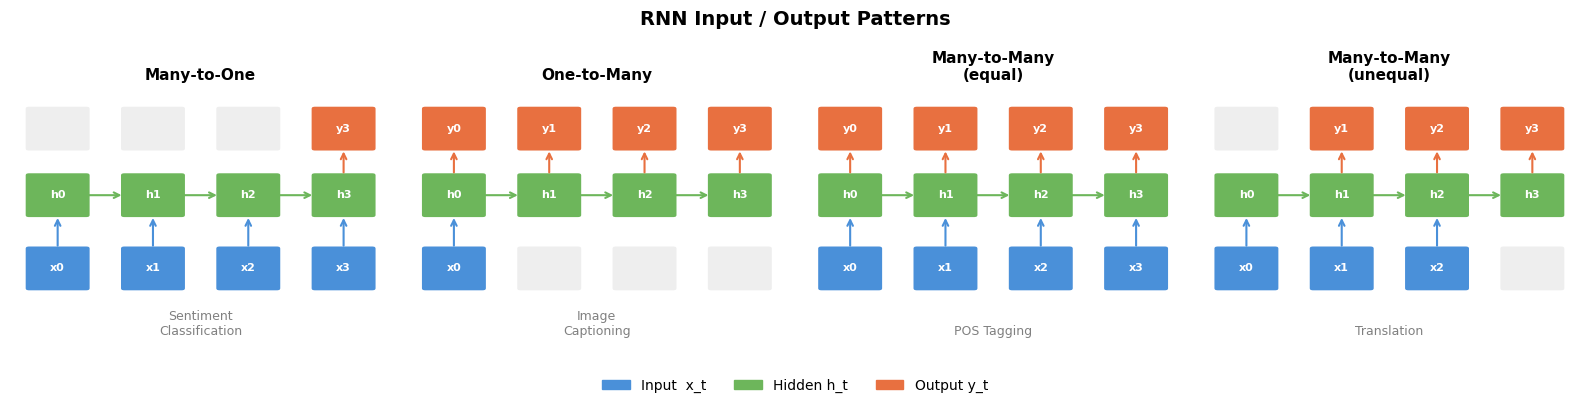

In [2]:
# ─────────────────────────────────────────────────
# Visualize the 4 RNN I/O patterns
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("RNN Input / Output Patterns", fontsize=14, fontweight='bold')

patterns = [
    {"title": "Many-to-One",        "example": "Sentiment\nClassification",
     "inputs": [1,1,1,1],  "outputs": [0,0,0,1]},
    {"title": "One-to-Many",        "example": "Image\nCaptioning",
     "inputs": [1,0,0,0],  "outputs": [1,1,1,1]},
    {"title": "Many-to-Many\n(equal)",   "example": "POS Tagging",
     "inputs": [1,1,1,1],  "outputs": [1,1,1,1]},
    {"title": "Many-to-Many\n(unequal)", "example": "Translation",
     "inputs": [1,1,1,0],  "outputs": [0,1,1,1]},
]

colors = {'input': '#4A90D9', 'output': '#E87040', 'hidden': '#6DB65B', 'none': '#EEEEEE'}

for ax, p in zip(axes, patterns):
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-1, 3)
    ax.set_title(p['title'], fontsize=11, fontweight='bold')
    ax.text(1.5, -0.7, p['example'], ha='center', fontsize=9, color='gray')
    ax.axis('off')

    for t in range(4):
        # Hidden state boxes
        fc = colors['hidden']
        rect = mpatches.FancyBboxPatch((t-0.3, 1.1), 0.6, 0.6,
            boxstyle="round,pad=0.05", facecolor=fc, edgecolor='white', linewidth=2)
        ax.add_patch(rect)
        ax.text(t, 1.4, f'h{t}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

        # Arrow between hidden states
        if t < 3:
            ax.annotate('', xy=(t+0.7, 1.4), xytext=(t+0.3, 1.4),
                        arrowprops=dict(arrowstyle='->', color='#6DB65B', lw=1.5))

        # Input boxes
        ic = colors['input'] if p['inputs'][t] else colors['none']
        rect2 = mpatches.FancyBboxPatch((t-0.3, 0.0), 0.6, 0.6,
            boxstyle="round,pad=0.05", facecolor=ic, edgecolor='white', linewidth=2)
        ax.add_patch(rect2)
        if p['inputs'][t]:
            ax.text(t, 0.3, f'x{t}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
            ax.annotate('', xy=(t, 1.1), xytext=(t, 0.6),
                        arrowprops=dict(arrowstyle='->', color='#4A90D9', lw=1.5))

        # Output boxes
        oc = colors['output'] if p['outputs'][t] else colors['none']
        rect3 = mpatches.FancyBboxPatch((t-0.3, 2.1), 0.6, 0.6,
            boxstyle="round,pad=0.05", facecolor=oc, edgecolor='white', linewidth=2)
        ax.add_patch(rect3)
        if p['outputs'][t]:
            ax.text(t, 2.4, f'y{t}', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
            ax.annotate('', xy=(t, 2.1), xytext=(t, 1.7),
                        arrowprops=dict(arrowstyle='->', color='#E87040', lw=1.5))

# Legend
legend_patches = [
    mpatches.Patch(color=colors['input'],  label='Input  x_t'),
    mpatches.Patch(color=colors['hidden'], label='Hidden h_t'),
    mpatches.Patch(color=colors['output'], label='Output y_t'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10, frameon=False)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

---
<a id='4'></a>
## 4. Backpropagation Through Time (BPTT)

Training an RNN uses the same principle as any neural network — **backpropagation** — but with a twist: because the network is unrolled across time, gradients flow **backwards through time steps**.

### How it works

1. **Forward pass:** Run the RNN from step $t=1$ to $t=T$, computing every hidden state $h_t$ and output $y_t$.
2. **Compute loss:** Compare each output $y_t$ to the target, sum the losses across all steps.
3. **Backward pass:** Compute gradients by going from $t=T$ back to $t=1$. Each time step's gradient depends on the next step's gradient (chain rule).

### The chain rule through time

At each step, the gradient of the loss with respect to an early hidden state $h_k$ involves multiplying many Jacobians together:

$$\frac{\partial L}{\partial h_k} = \frac{\partial L}{\partial h_T} \cdot \prod_{t=k}^{T-1} \frac{\partial h_{t+1}}{\partial h_t}$$

This product of matrices is where the trouble begins…

### Truncated BPTT

For very long sequences, backpropagating all the way to the beginning is computationally expensive (and numerically unstable). In practice, we use **Truncated BPTT**: we only backpropagate through the last $k$ steps, cutting off gradients beyond a fixed window. This is the standard in production training.

---
<a id='5'></a>
## 5. The Vanishing & Exploding Gradient Problem

This is arguably the **most important concept** to understand about vanilla RNNs. It explains why LSTMs were invented.

### The intuition

Recall that in BPTT we multiply many Jacobians together:

$$\prod_{t=k}^{T-1} \frac{\partial h_{t+1}}{\partial h_t} = \prod_{t=k}^{T-1} W_{hh}^\top \cdot \text{diag}(\tanh'(\cdot))$$

Each factor is roughly $W_{hh}$ scaled by the derivative of $\tanh$. Now think about what happens when you multiply a number repeatedly:

- If that number is **< 1** (say, 0.9): $0.9^{100} \approx 0.000027$ → **vanishes** to zero
- If that number is **> 1** (say, 1.1): $1.1^{100} \approx 13,781$ → **explodes** to infinity

The same happens to matrices — their eigenvalues determine whether repeated multiplication shrinks or explodes.

### Consequences

| Problem | What happens | Effect on learning |
|---|---|---|
| **Vanishing gradients** | Gradients for early time steps ≈ 0 | Network can't learn **long-term dependencies** |
| **Exploding gradients** | Gradients become huge | Training **diverges** (loss goes to NaN) |

### Practical fix for exploding gradients: Gradient Clipping

If the gradient norm exceeds a threshold, scale it down. This is simple and effective:

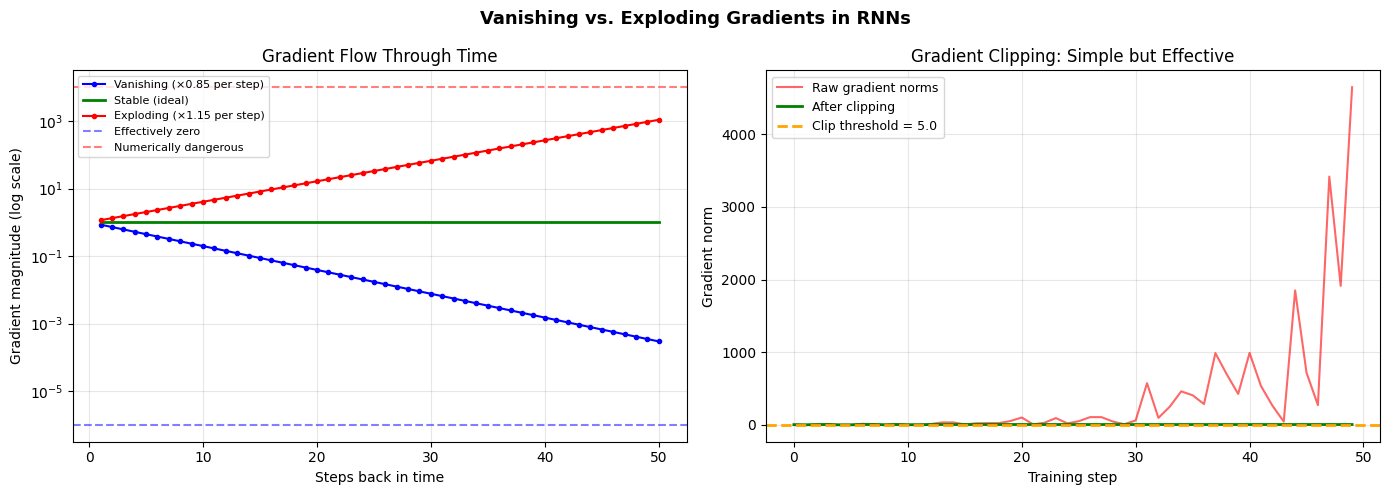


💡 Key insight:
  Vanishing gradients → RNN can't credit early inputs for later outcomes
  Exploding gradients → training becomes numerically unstable
  Gradient clipping fixes exploding, but NOT vanishing — we need LSTMs for that.


In [3]:
# ─────────────────────────────────────────────────
# Demonstrate vanishing gradients visually
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Vanishing vs. Exploding Gradients in RNNs", fontsize=13, fontweight='bold')

steps = np.arange(1, 51)

# Simulate gradient norms at each step back in time
# (multiplying by a scalar approximates the eigenvalue behavior)
vanishing   = 0.85 ** steps     # eigenvalue < 1
exploding   = 1.15 ** steps     # eigenvalue > 1
stable      = np.ones_like(steps, dtype=float)  # ideal

# Left plot: gradient magnitude over time steps
ax = axes[0]
ax.semilogy(steps, vanishing, 'b-o', markersize=3, label='Vanishing (×0.85 per step)')
ax.semilogy(steps, stable,    'g-',  linewidth=2,  label='Stable (ideal)')
ax.semilogy(steps, exploding, 'r-o', markersize=3, label='Exploding (×1.15 per step)')
ax.axhline(1e-6, color='blue',  linestyle='--', alpha=0.5, label='Effectively zero')
ax.axhline(1e4,  color='red',   linestyle='--', alpha=0.5, label='Numerically dangerous')
ax.set_xlabel("Steps back in time")
ax.set_ylabel("Gradient magnitude (log scale)")
ax.set_title("Gradient Flow Through Time")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right plot: gradient clipping illustration
ax2 = axes[1]
np.random.seed(42)
raw_norms   = np.abs(np.random.randn(50) * 3 + 1) * exploding[:50]
clip_thresh = 5.0
clipped     = np.minimum(raw_norms, clip_thresh)

ax2.plot(raw_norms, 'r-', alpha=0.6, label='Raw gradient norms')
ax2.plot(clipped,   'g-', linewidth=2, label='After clipping')
ax2.axhline(clip_thresh, color='orange', linestyle='--', linewidth=2, label=f'Clip threshold = {clip_thresh}')
ax2.set_xlabel("Training step")
ax2.set_ylabel("Gradient norm")
ax2.set_title("Gradient Clipping: Simple but Effective")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Key insight:")
print("  Vanishing gradients → RNN can't credit early inputs for later outcomes")
print("  Exploding gradients → training becomes numerically unstable")
print("  Gradient clipping fixes exploding, but NOT vanishing — we need LSTMs for that.")

### Why $\tanh$ makes vanishing worse

The derivative of $\tanh$ is $1 - \tanh^2(x)$, which is **at most 1** and is close to 0 at the extremes (when the input is very large or very small). As the RNN's hidden state gets pushed to saturation, gradients get crushed at every step — making the vanishing problem even more severe.

This is the fundamental flaw of the vanilla RNN. The solution? **Give the network a way to preserve information across many time steps without repeatedly multiplying it by matrices.**

---
<a id='6'></a>
## 6. Long Short-Term Memory (LSTM)

LSTMs were introduced by **Hochreiter & Schmidhuber in 1997** and became the dominant sequence model for nearly 20 years (until Transformers). The core idea is elegant:

> **Instead of one hidden state, maintain two: a hidden state $h_t$ (short-term) and a cell state $c_t$ (long-term). Control information flow using learned gates.**

### The Cell State: The Long-Term Highway

The cell state $c_t$ runs straight through the network with only **additive** (not multiplicative) updates:

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

Addition is crucial: gradients can flow backwards along $c$ **without** being multiplied by the recurrent weight matrix at every step, dramatically reducing vanishing gradients.

### The Three Gates

Gates are vectors of values between 0 and 1 (produced by sigmoid functions). They multiply element-wise with the cell/hidden state to control how much information passes through. Think of them as **valves**.

---

#### 🚪 Gate 1: Forget Gate $f_t$

**"What should I erase from my long-term memory?"**

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

- Output is between 0 and 1 for each cell state dimension
- **0** → completely forget this value  
- **1** → completely keep this value

*Example:* When translating and you finish a clause, you want to forget the gender of the previous noun.

---

#### 🚪 Gate 2: Input Gate $i_t$ + Candidate $\tilde{c}_t$

**"What new information should I write into long-term memory?"**

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$

- $i_t$ decides **whether** to write (gate)  
- $\tilde{c}_t$ is the **candidate** value to write (ranges $[-1, 1]$)

---

#### 🚪 Gate 3: Output Gate $o_t$

**"What part of my long-term memory should influence the output right now?"**

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

$$h_t = o_t \odot \tanh(c_t)$$

The output gate filters what part of the cell state to expose as the hidden state $h_t$.

---

### Putting It All Together

```
c_{t-1} ──────────────────────────────────────────────────────────→ c_t
              ×                          +
             f_t (forget)          i_t × c̃_t (input/write)

h_{t-1} ──┐   ↑                         ↑
           ├──→ Forget gate          Input gate  + Candidate
           ├──→ Input gate                               ↓
           └──→ Output gate ────────→  h_t = o_t × tanh(c_t)
x_t ──────┘
```

### Why does this solve vanishing gradients?

The cell state update is additive: $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$

When the gradient flows back through time along the $c$ pathway, it only encounters:
- **Addition** (gradient flows through directly)
- **Element-wise multiplication by $f_t$** (not a full matrix multiply!)

If the forget gate learns to be close to 1, gradients can flow back essentially unchanged over hundreds of steps. This is the LSTM's superpower.

In [4]:
# ─────────────────────────────────────────────────
# LSTM cell — implemented from scratch
# Annotated carefully so you can follow each gate
# ─────────────────────────────────────────────────

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -100, 100)))

class LSTMCell:
    """A single LSTM cell: processes one time step."""
    
    def __init__(self, input_size, hidden_size):
        scale = 0.1
        d = hidden_size
        
        # Each gate has weights for both x and h, plus a bias
        # In efficient implementations all 4 gates are computed in one big matrix multiply
        self.W = np.random.randn(4 * d, input_size + d) * scale  # [Wf, Wi, Wc, Wo]
        self.b = np.zeros((4 * d, 1))
        self.hidden_size = d
    
    def forward(self, x_t, h_prev, c_prev):
        d = self.hidden_size
        
        # Concatenate input and previous hidden state
        combined = np.vstack([h_prev, x_t])   # shape: (hidden + input, 1)
        
        # Compute all 4 gate pre-activations in one step (efficient!)
        gates = self.W @ combined + self.b     # shape: (4*d, 1)
        
        # Split into individual gates
        f_raw, i_raw, c_raw, o_raw = np.split(gates, 4, axis=0)
        
        f_t = sigmoid(f_raw)         # Forget gate:    values in [0, 1]
        i_t = sigmoid(i_raw)         # Input gate:     values in [0, 1]
        c_candidate = np.tanh(c_raw) # Candidate:      values in [-1, 1]
        o_t = sigmoid(o_raw)         # Output gate:    values in [0, 1]
        
        # Update cell state (the long-term memory highway)
        c_t = f_t * c_prev + i_t * c_candidate   # element-wise!
        
        # Compute new hidden state (short-term, what we expose)
        h_t = o_t * np.tanh(c_t)
        
        return h_t, c_t, {'f': f_t, 'i': i_t, 'o': o_t, 'c_cand': c_candidate}


# ─── Run LSTM on a toy sequence and inspect gate activations ───
input_size  = 4
hidden_size = 6
seq_length  = 8

lstm = LSTMCell(input_size, hidden_size)

h = np.zeros((hidden_size, 1))
c = np.zeros((hidden_size, 1))

print("LSTM gate activations at each time step")
print("(values closer to 1 = 'open', closer to 0 = 'closed')\n")
print(f"{'Step':>4}  {'Forget (mean)':>15}  {'Input (mean)':>13}  {'Output (mean)':>14}  {'|c_t| norm':>11}")
print("-" * 65)

for t in range(seq_length):
    x_t = np.random.randn(input_size, 1)
    h, c, gates = lstm.forward(x_t, h, c)
    print(f"  {t+1:2d}    {gates['f'].mean():>14.3f}  {gates['i'].mean():>13.3f}  "
          f"{gates['o'].mean():>13.3f}  {np.linalg.norm(c):>11.4f}")

print("\n✅ Notice: forget gate ≈ 0.5 initially (untrained). After training,")
print("   the model learns WHEN to open/close each gate for the specific task.")

LSTM gate activations at each time step
(values closer to 1 = 'open', closer to 0 = 'closed')

Step    Forget (mean)   Input (mean)   Output (mean)   |c_t| norm
-----------------------------------------------------------------
   1             0.489          0.497          0.505       0.1871
   2             0.500          0.506          0.514       0.1791
   3             0.512          0.495          0.486       0.0786
   4             0.510          0.496          0.495       0.1154
   5             0.512          0.503          0.511       0.1369
   6             0.501          0.497          0.496       0.2827
   7             0.515          0.501          0.504       0.1827
   8             0.499          0.498          0.505       0.2285

✅ Notice: forget gate ≈ 0.5 initially (untrained). After training,
   the model learns WHEN to open/close each gate for the specific task.


### Interpreting Learned Gates (Conceptual Examples)

After training, LSTM gates develop meaningful behaviors:

| Scenario (language modeling) | Gate behavior |
|---|---|
| See a period "." → new sentence starting | **Forget gate** opens → reset context |
| See a subject noun ("The cat") | **Input gate** opens → write subject to cell |
| Generating a verb | **Output gate** opens → expose subject from memory |
| Middle of a long prepositional phrase | **Forget gate** closes → preserve subject across the phrase |

This interpretability (relative to the vanilla RNN) is one reason LSTMs were so successful.

---
<a id='7'></a>
## 7. Gated Recurrent Unit (GRU) — A Simpler Alternative

Introduced by **Cho et al. (2014)**, the GRU is a streamlined version of the LSTM. It merges the forget and input gates into a single **update gate** and eliminates the separate cell state:

### GRU Equations

$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$ **Update gate** — how much of the old hidden state to keep

$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$ **Reset gate** — how much of the old state to use when computing candidate

$$\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t])$$ **Candidate** hidden state

$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$ **Final** hidden state

### LSTM vs. GRU at a glance

| | LSTM | GRU |
|---|---|---|
| Gates | 3 (forget, input, output) | 2 (update, reset) |
| States | 2 ($h_t$ and $c_t$) | 1 ($h_t$ only) |
| Parameters | More | Fewer (~33% less) |
| Training speed | Slower | Faster |
| Performance | Often slightly better on long sequences | Competitive on shorter ones |
| When to use | Long-range dependencies needed | Faster training, smaller data |

In practice, the performance gap between LSTM and GRU is often small, and the right choice is task-dependent. Both are vastly superior to vanilla RNNs for long sequences.

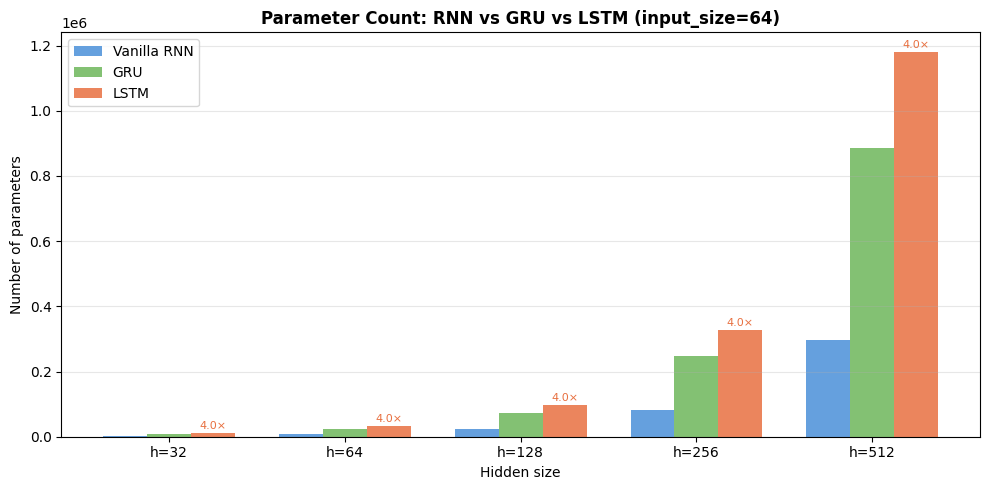

The orange annotations show how many times MORE parameters LSTM has vs vanilla RNN.
GRU is a good middle ground: ~3× RNN parameters, ~75% of LSTM parameters.


In [5]:
# ─────────────────────────────────────────────────
# Compare parameter counts: RNN vs GRU vs LSTM
# ─────────────────────────────────────────────────

def rnn_params(input_size, hidden_size):
    # W_xh + W_hh + bias
    return hidden_size * input_size + hidden_size * hidden_size + hidden_size

def gru_params(input_size, hidden_size):
    # 3 gate weight matrices (z, r, h_candidate), each: W_x + W_h + bias
    per_gate = hidden_size * input_size + hidden_size * hidden_size + hidden_size
    return 3 * per_gate

def lstm_params(input_size, hidden_size):
    # 4 gate weight matrices (f, i, c, o), each: W_x + W_h + bias
    per_gate = hidden_size * input_size + hidden_size * hidden_size + hidden_size
    return 4 * per_gate

hidden_sizes = [32, 64, 128, 256, 512]
input_size   = 64

rnn_counts  = [rnn_params(input_size, h)  for h in hidden_sizes]
gru_counts  = [gru_params(input_size, h)  for h in hidden_sizes]
lstm_counts = [lstm_params(input_size, h) for h in hidden_sizes]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(hidden_sizes))
w = 0.25

ax.bar(x - w,   rnn_counts,  w, label='Vanilla RNN', color='#4A90D9', alpha=0.85)
ax.bar(x,       gru_counts,  w, label='GRU',         color='#6DB65B', alpha=0.85)
ax.bar(x + w,   lstm_counts, w, label='LSTM',        color='#E87040', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'h={h}' for h in hidden_sizes])
ax.set_xlabel('Hidden size')
ax.set_ylabel('Number of parameters')
ax.set_title('Parameter Count: RNN vs GRU vs LSTM (input_size=64)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate the ratio
for i, h in enumerate(hidden_sizes):
    ratio = lstm_counts[i] / rnn_counts[i]
    ax.text(i + w, lstm_counts[i] + max(lstm_counts)*0.01, f'{ratio:.1f}×', 
            ha='center', fontsize=8, color='#E87040')

plt.tight_layout()
plt.show()

print("The orange annotations show how many times MORE parameters LSTM has vs vanilla RNN.")
print("GRU is a good middle ground: ~3× RNN parameters, ~75% of LSTM parameters.")

---
<a id='8'></a>
## 8. Practical Considerations

### Stacking RNN Layers (Deep RNNs)

Just like stacking linear layers gives a deeper MLP, you can stack LSTM layers. The output sequence of one LSTM layer becomes the input sequence of the next. This allows the model to learn more abstract temporal representations at higher layers.

```
Layer 3:    h₃₀  h₃₁  h₃₂  h₃₃  ...   (most abstract)
               ↑    ↑    ↑    ↑
Layer 2:    h₂₀  h₂₁  h₂₂  h₂₃  ...
               ↑    ↑    ↑    ↑
Layer 1:    h₁₀  h₁₁  h₁₂  h₁₃  ...   (closest to input)
               ↑    ↑    ↑    ↑
Inputs:      x₀   x₁   x₂   x₃
```

### Bidirectional RNNs

A standard RNN processes left-to-right and can only see past context. A **Bidirectional RNN** runs two RNNs — one forward, one backward — and concatenates their hidden states:

$$h_t^{\text{bi}} = [\overrightarrow{h_t}, \overleftarrow{h_t}]$$

This is extremely useful for tasks where future context matters (e.g., named entity recognition: "I met **Paris** Hilton" vs "I visited **Paris** yesterday"). However, it's only applicable when the full sequence is available at inference time (so NOT for real-time text generation).

### Dropout in RNNs

Standard dropout applied to recurrent connections hurts training significantly. The recommended approach is **Variational Dropout** (Gal & Ghahramani, 2016): apply the *same* dropout mask at every time step rather than a different one, preserving the network's ability to carry information through time.

### Common Hyperparameters to Tune

| Hyperparameter | Typical range | Notes |
|---|---|---|
| Hidden size | 64 – 1024 | Bigger = more capacity & more compute |
| Num layers | 1 – 4 | Diminishing returns beyond 3-4 |
| Learning rate | 1e-4 – 1e-2 | Use learning rate scheduler |
| Gradient clip | 0.5 – 5.0 | Almost always use this |
| Dropout | 0.1 – 0.5 | Between layers (not within recurrent step) |
| Sequence length (truncated BPTT) | 20 – 200 | Task-dependent |

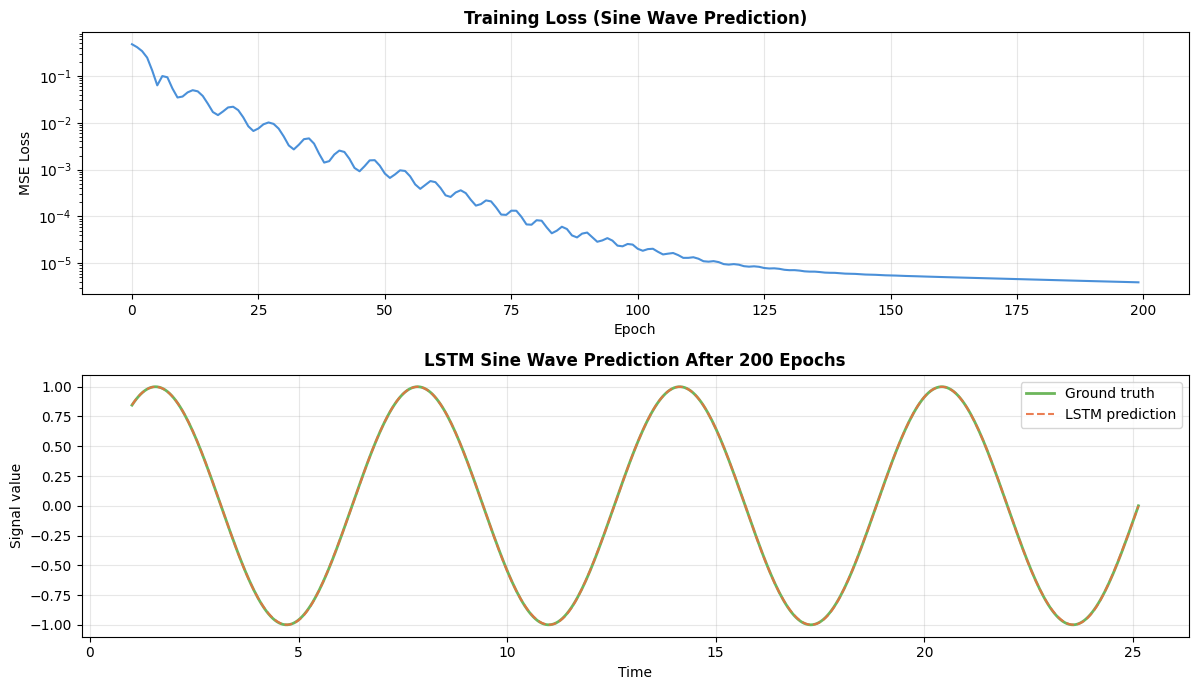

Model parameters: 4,513
Final loss: 0.000004


In [6]:
# ─────────────────────────────────────────────────
# Quick demo: PyTorch LSTM on a sine wave prediction task
# Shows how to use the API — the concepts above do all the heavy lifting
# ─────────────────────────────────────────────────

import torch
import torch.nn as nn

# ── Generate sine wave data ──
torch.manual_seed(0)
t = torch.linspace(0, 8 * np.pi, 500)
signal = torch.sin(t).unsqueeze(1)           # shape: (500, 1)

# Sliding window: predict step t+1 from steps t-19 to t
seq_len = 20
X = torch.stack([signal[i:i+seq_len]   for i in range(len(signal) - seq_len)])
y = torch.stack([signal[i+seq_len]     for i in range(len(signal) - seq_len)])
# X: (N, seq_len, 1),  y: (N, 1)

# ── Define a simple LSTM regression model ──
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm   = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.lstm(x)         # out: (batch, seq_len, hidden_size)
        return self.linear(out[:, -1, :])  # use last time step's hidden state

model     = LSTMPredictor()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# ── Train ──
losses = []
model.train()
for epoch in range(200):
    pred = model(X)
    loss = criterion(pred, y)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping!
    optimizer.step()
    losses.append(loss.item())

# ── Plot results ──
model.eval()
with torch.no_grad():
    predictions = model(X).squeeze().numpy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

ax1.plot(losses, color='#4A90D9', linewidth=1.5)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training Loss (Sine Wave Prediction)', fontweight='bold')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(t[seq_len:].numpy(), signal[seq_len:].squeeze().numpy(),
         label='Ground truth', linewidth=2, color='#6DB65B')
ax2.plot(t[seq_len:].numpy(), predictions,
         label='LSTM prediction', linewidth=1.5, linestyle='--', color='#E87040', alpha=0.9)
ax2.set_xlabel('Time')
ax2.set_ylabel('Signal value')
ax2.set_title('LSTM Sine Wave Prediction After 200 Epochs', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Final loss: {losses[-1]:.6f}")

> **Bottom line:** Understanding RNNs and LSTMs is foundational — both historically (they enabled the AI breakthroughs of the 2010s) and practically (they remain the right tool for many real-time and resource-constrained applications).

---
<a id='10'></a>
## 10. Summary & Key Takeaways

| Concept | One-line summary |
|---|---|
| **RNN motivation** | Feedforward networks can't handle sequences — no memory of past inputs |
| **RNN mechanics** | Hidden state $h_t$ = function of current input + previous hidden state |
| **Weight sharing** | Same weights at every time step → handles variable-length sequences |
| **BPTT** | Backpropagation through unrolled time steps |
| **Vanishing gradients** | Multiplying many small numbers → early gradients ≈ 0 → no long-term memory |
| **Exploding gradients** | Multiplying many large numbers → gradients → ∞ → training diverges |
| **Gradient clipping** | Caps gradient norm — fixes exploding but NOT vanishing |
| **LSTM** | Adds cell state (additive updates) + 3 gates → solves vanishing gradient |
| **LSTM gates** | Forget (erase), Input (write), Output (read from long-term memory) |
| **GRU** | Simpler LSTM: 2 gates, 1 state — fewer parameters, often competitive |
| **Bidirectional** | Two RNNs (forward + backward) → context from both directions |
| **Current status** | Transformers dominate NLP; RNNs/LSTMs excel at real-time & edge tasks |